<a href="https://colab.research.google.com/github/mihirmaurya31/XAI-for-Phishing-URL-detection/blob/main/eda_phish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Pre-processing Phase- Understanding the data basics!**

Url -- string (datatype object)

Label -- initially int64 for binary classification ( o or 1) but it can be Bool value as well (True or False)


Lexical count feature group -- int64 because it will be give quantity of no of dots, hyphen, @, &,_ and stuff.

Length features -- int64 because it will give the length of string
such as directory_length, file_length, params_length and stuff.

Network and Response feature group --  time_response is int64 but can be float64 as well because decimals can be possible as well.

qty_redirects -- int64 because it shows number of redirects.

http_status -- int64 shows status code 404,200.

server_header -- it can be object (string) as it is a categorical value.

tls_ssl_certificate -- is int64 initially but we need to check whether ssl certificate is present or not so it can be a bool value as well (True and False).





**Initial check how every column looks like**

In [3]:
import pandas as pd

#Read only a small sample to infer dtypes ----
sample_df = pd.read_csv("final_features_dataset.csv", nrows=None)

#Display column datatypes ----
print("=== COLUMN DATA TYPES ===")
#The output below shows the datatypes for all 115 columns
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(sample_df.dtypes)
print("\nTotal columns:", len(sample_df.columns))


#the first few rows ----
#print("\n=== FIRST 5 ROWS ===")
#print(sample_df.head())


=== COLUMN DATA TYPES ===
url                            object
Label                         float64
qty_dot_url                     int64
qty_hyphen_url                  int64
qty_underline_url               int64
qty_slash_url                   int64
qty_questionmark_url            int64
qty_equal_url                   int64
qty_at_url                      int64
qty_and_url                     int64
qty_exclamation_url             int64
qty_space_url                   int64
qty_tilde_url                   int64
qty_comma_url                   int64
qty_plus_url                    int64
qty_asterisk_url                int64
qty_hashtag_url                 int64
qty_dollar_url                  int64
qty_percent_url                 int64
length_url                    float64
qty_dot_domain                float64
qty_hyphen_domain             float64
qty_underline_domain          float64
qty_slash_domain              float64
qty_questionmark_domain       float64
qty_equal_domain        

In [4]:
print(sample_df['Label'].value_counts())


Label
1.0    39049
0.0       94
Name: count, dtype: int64


In [5]:
# Convert Label from float to boolean
sample_df['Label'] = sample_df['Label'].astype(bool)

# Verify the change
print(sample_df['Label'].dtype)
print(sample_df['Label'].value_counts())

bool
Label
True     39063
False       94
Name: count, dtype: int64


so we have 89.90% URls as Legitimate and 10.10% URls as phishing

In [7]:

import pandas as pd

# Load dataset (already bool)
sample_df = pd.read_csv("final_features_dataset.csv", low_memory=False)
sample_df['Label'] = sample_df['Label'].astype(bool)

# Count True/False
counts = sample_df['Label'].value_counts()
percentages = (counts / counts.sum()) * 100

# Display neatly
print("=== Label Distribution ===")
for label, count in counts.items():
    meaning = "Phishing" if label else "Legitimate"
    print(f"{meaning} ({label}): {count:,} URLs ({percentages[label]:.2f}%)")


=== Label Distribution ===
Phishing (True): 47,918 URLs (62.21%)
Legitimate (False): 29,103 URLs (37.79%)


In [8]:
import pandas as pd

#Load your dataset
samplesample0_df = pd.read_csv("final_features_dataset.csv", low_memory=False)

# List of columns to convert
cols_to_convert = [
    'qty_plus_params', 'qty_asterisk_params', 'qty_hashtag_params', 'qty_dollar_params',
    'qty_percent_params', 'params_length', 'qty_dot_fragment', 'qty_hyphen_fragment',
    'qty_underline_fragment', 'qty_slash_fragment', 'qty_questionmark_fragment',
    'qty_equal_fragment', 'qty_at_fragment', 'qty_and_fragment', 'qty_exclamation_fragment',
    'qty_space_fragment', 'qty_tilde_fragment', 'qty_comma_fragment', 'qty_plus_fragment',
    'qty_asterisk_fragment', 'qty_hashtag_fragment', 'qty_dollar_fragment',
    'qty_percent_fragment', 'fragment_length', 'time_response', 'qty_redirects','http_status', 'tls_ssl_certificate'
]

# Convert to int64 safely (handling NaN)
sample_df[cols_to_convert] = sample_df[cols_to_convert].fillna(0).astype('int64')

# Verify changes
print(sample_df[cols_to_convert].dtypes)


qty_plus_params              int64
qty_asterisk_params          int64
qty_hashtag_params           int64
qty_dollar_params            int64
qty_percent_params           int64
params_length                int64
qty_dot_fragment             int64
qty_hyphen_fragment          int64
qty_underline_fragment       int64
qty_slash_fragment           int64
qty_questionmark_fragment    int64
qty_equal_fragment           int64
qty_at_fragment              int64
qty_and_fragment             int64
qty_exclamation_fragment     int64
qty_space_fragment           int64
qty_tilde_fragment           int64
qty_comma_fragment           int64
qty_plus_fragment            int64
qty_asterisk_fragment        int64
qty_hashtag_fragment         int64
qty_dollar_fragment          int64
qty_percent_fragment         int64
fragment_length              int64
time_response                int64
qty_redirects                int64
http_status                  int64
tls_ssl_certificate          int64
dtype: object


In [9]:
print(sample_df.dtypes.value_counts())
print(sample_df['server_header'].value_counts())

int64     112
object      2
bool        1
Name: count, dtype: int64
server_header
cloudflare                                                   8483
Apache                                                       6181
nginx                                                        4020
LiteSpeed                                                    1160
nginx/1.18.0                                                  964
                                                             ... 
Apache/2.4.64 ()                                                1
mw-web.eqiad.main-79d474f4c8-p9tgx                              1
mw-web.eqiad.main-8d8c58796-7rlq4                               1
Apache/2.4.63 (Rocky Linux) OpenSSL/3.2.2 mod_fcgid/2.3.9       1
Acumatica WebServer                                             1
Name: count, Length: 1034, dtype: int64


**Check missing values per column**

In [10]:
import pandas as pd

# Count missing values
missing_values = sample_df.isna().sum()

# Display
print(missing_values)

missing_report = (
    sample_df.isna().sum()
    .to_frame('Missing_Count')
    .assign(Missing_Percent=lambda x: (x['Missing_Count'] / len(sample_df)) * 100)
    .sort_values('Missing_Percent', ascending=False)
)

print("=== MISSING VALUE REPORT ===")
print(missing_report)



url                        0
Label                      0
qty_dot_url                0
qty_hyphen_url             0
qty_underline_url          0
                       ...  
time_response              0
qty_redirects              0
http_status                0
server_header          43710
tls_ssl_certificate        0
Length: 115, dtype: int64
=== MISSING VALUE REPORT ===
                      Missing_Count  Missing_Percent
server_header                 43710        56.750756
Label                             0         0.000000
url                               0         0.000000
qty_hyphen_url                    0         0.000000
qty_underline_url                 0         0.000000
...                             ...              ...
qty_percent_fragment              0         0.000000
time_response                     0         0.000000
qty_redirects                     0         0.000000
http_status                       0         0.000000
tls_ssl_certificate               0        

so we have Missing values in server_header and http_status
we can fix it using imputation method server_header datatype is object (Apache,Nginx) so we can impute Unknown. And in the server_header datatype is int64 datatype so we can impute (-1) basically it will show no response received from the URLs.

In [11]:
sample_df['server_header'] = sample_df['server_header'].fillna('Unknown')
sample_df['http_status'] = sample_df['http_status'].fillna(-1)
print(sample_df['http_status'].value_counts())
print(sample_df['server_header'].value_counts())

http_status
0      39516
200    15862
404    12056
429     2887
403     2855
405     1660
500      504
400      405
504      267
410      219
503      198
520      131
406       92
444       80
502       51
401       41
409       31
526       24
521       17
416       15
999       14
412       12
202       11
522       11
418        8
530        8
204        6
501        5
415        5
307        4
402        4
301        3
302        3
523        2
525        2
300        2
421        2
556        1
509        1
422        1
423        1
510        1
508        1
441        1
426        1
Name: count, dtype: int64
server_header
Unknown                                                      43710
cloudflare                                                    8483
Apache                                                        6181
nginx                                                         4020
LiteSpeed                                                     1160
                            

**Fianl check for missing values**

In [12]:
import pandas as pd

# Assuming your DataFrame is named sample_df
missing_report = (
    sample_df.isna().sum()
    .to_frame('Missing_Count')
    .assign(Missing_Percent=lambda x: (x['Missing_Count'] / len(sample_df)) * 100)
    .sort_values('Missing_Percent', ascending=False)
)

print("=== MISSING VALUE REPORT ===")
print(missing_report)


=== MISSING VALUE REPORT ===
                     Missing_Count  Missing_Percent
url                              0              0.0
Label                            0              0.0
qty_dot_url                      0              0.0
qty_hyphen_url                   0              0.0
qty_underline_url                0              0.0
...                            ...              ...
time_response                    0              0.0
qty_redirects                    0              0.0
http_status                      0              0.0
server_header                    0              0.0
tls_ssl_certificate              0              0.0

[115 rows x 2 columns]


**Final look for the columns**

In [13]:
#Display column datatypes ----
print("=== COLUMN DATA TYPES ===")
#The output below shows the datatypes for all 115 columns
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(sample_df.dtypes)
print("\nTotal columns:", len(sample_df.columns))


=== COLUMN DATA TYPES ===
url                           object
Label                           bool
qty_dot_url                    int64
qty_hyphen_url                 int64
qty_underline_url              int64
qty_slash_url                  int64
qty_questionmark_url           int64
qty_equal_url                  int64
qty_at_url                     int64
qty_and_url                    int64
qty_exclamation_url            int64
qty_space_url                  int64
qty_tilde_url                  int64
qty_comma_url                  int64
qty_plus_url                   int64
qty_asterisk_url               int64
qty_hashtag_url                int64
qty_dollar_url                 int64
qty_percent_url                int64
length_url                     int64
qty_dot_domain                 int64
qty_hyphen_domain              int64
qty_underline_domain           int64
qty_slash_domain               int64
qty_questionmark_domain        int64
qty_equal_domain               int64
qty_at_domai

In [14]:
print(sample_df['tls_ssl_certificate'].value_counts())

tls_ssl_certificate
0    77021
Name: count, dtype: int64


In [15]:
import pandas as pd

# Confirm missing values
total_missing = sample_df.isna().sum().sum()

if total_missing == 0:
    print(" No missing values detected in the dataset!")
else:
    print(f" There are still {total_missing} missing values present.")


 No missing values detected in the dataset!


**Final script of the cleaned dataset**

In [16]:
import pandas as pd

# 1️ Load your dataset
sample_df = pd.read_csv("final_features_dataset.csv", low_memory=False)

# 2️ Convert Label from float64 → bool
sample_df['Label'] = sample_df['Label'].astype(bool)

# 3️ Convert these numeric float columns → int64
cols_to_convert = [
    'qty_plus_params', 'qty_asterisk_params', 'qty_hashtag_params', 'qty_dollar_params',
    'qty_percent_params', 'params_length', 'qty_dot_fragment', 'qty_hyphen_fragment',
    'qty_underline_fragment', 'qty_slash_fragment', 'qty_questionmark_fragment',
    'qty_equal_fragment', 'qty_at_fragment', 'qty_and_fragment', 'qty_exclamation_fragment',
    'qty_space_fragment', 'qty_tilde_fragment', 'qty_comma_fragment', 'qty_plus_fragment',
    'qty_asterisk_fragment', 'qty_hashtag_fragment', 'qty_dollar_fragment',
    'qty_percent_fragment', 'fragment_length', 'time_response', 'qty_redirects',
    'http_status', 'tls_ssl_certificate'
]

sample_df[cols_to_convert] = sample_df[cols_to_convert].fillna(0).astype('int64')

# 4️ Handle missing categorical and numeric values (already confirmed but safe to reapply)
sample_df['server_header'] = sample_df['server_header'].fillna('Unknown')
sample_df['http_status'] = sample_df['http_status'].fillna(-1).astype(int)

# 5️ Confirm all missing values handled
print("Missing values:", sample_df.isna().sum().sum())

# 6️ Save the final cleaned dataset
sample_df.to_csv("final_features_cleaned_dataset.csv", index=False)

print("Final cleaned dataset saved as: final_features_cleaned_dataset.csv")
print("Shape:", sample_df.shape)


Missing values: 0
Final cleaned dataset saved as: final_features_cleaned_dataset.csv
Shape: (165295, 115)


**EDA**

In [26]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt

# Ensure Label is bool
sample_df["Label"] = sample_df["Label"].astype(bool)

# Drop non-feature columns
drop_cols = ["url", "server_header"]
X = sample_df.drop(columns=[c for c in drop_cols if c in sample_df.columns] + ["Label"])
y = sample_df["Label"]

# Encode any remaining non-numeric columns
non_numeric = X.select_dtypes(include=["object", "category"]).columns
if len(non_numeric) > 0:
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X[non_numeric] = enc.fit_transform(X[non_numeric])

# Compute Mutual Information
mi = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    "feature": X.columns,
    "mutual_information": mi
}).sort_values("mutual_information", ascending=False)

print("=== TOP 20 FEATURES BY MUTUAL INFORMATION ===")
print(mi_df.head(20))


=== TOP 20 FEATURES BY MUTUAL INFORMATION ===
                  feature  mutual_information
110           http_status            0.150472
18         qty_dot_domain            0.103233
108         time_response            0.097640
17             length_url            0.091505
109         qty_redirects            0.076649
3           qty_slash_url            0.069507
0             qty_dot_url            0.064395
89          params_length            0.059653
39    qty_slash_directory            0.047421
53       directory_length            0.047299
35          domain_length            0.041157
5           qty_equal_url            0.040439
4    qty_questionmark_url            0.037435
71            file_length            0.036069
36      qty_dot_directory            0.034927
77       qty_equal_params            0.033946
7             qty_and_url            0.032898
79         qty_and_params            0.030686
72         qty_dot_params            0.026803
73      qty_hyphen_params         

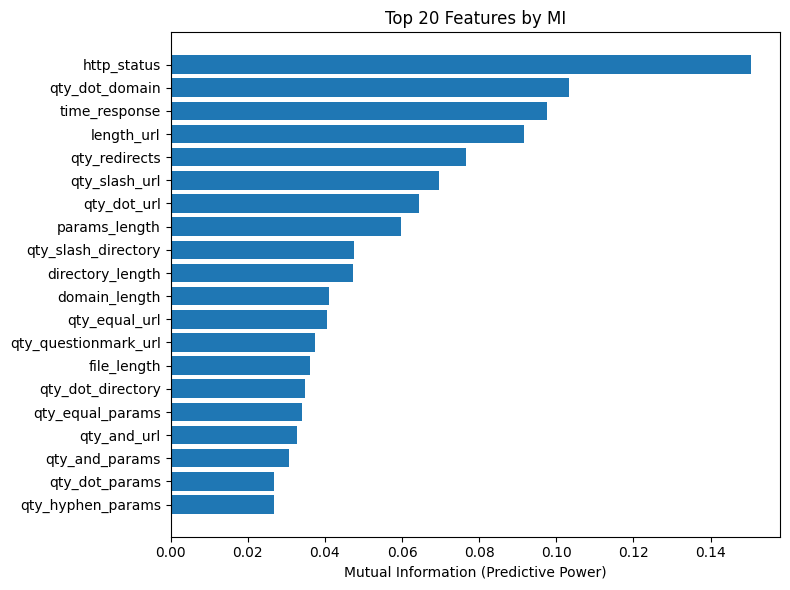

In [27]:
top_k = 20
top_mi = mi_df.head(top_k).sort_values("mutual_information")

plt.figure(figsize=(8, 6))
plt.barh(top_mi["feature"], top_mi["mutual_information"])
plt.xlabel("Mutual Information (Predictive Power)")
plt.title(f"Top {top_k} Features by MI")
plt.tight_layout()
plt.show()




--- Plotting http_status ---


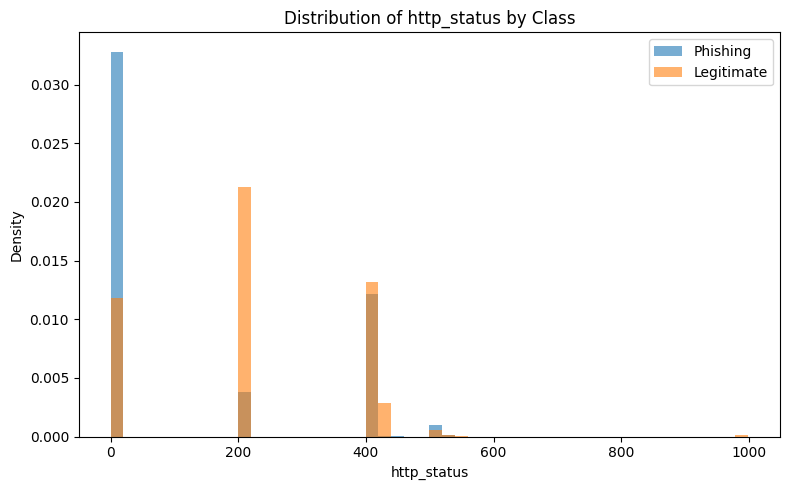


--- Plotting qty_dot_domain ---


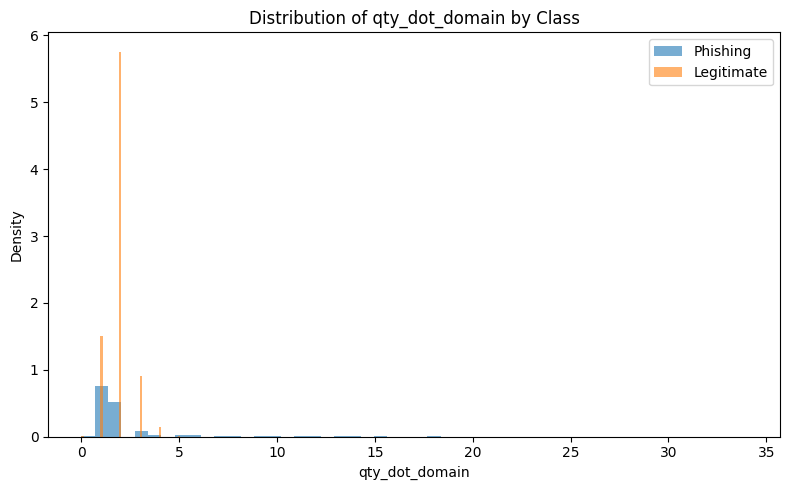


--- Plotting time_response ---


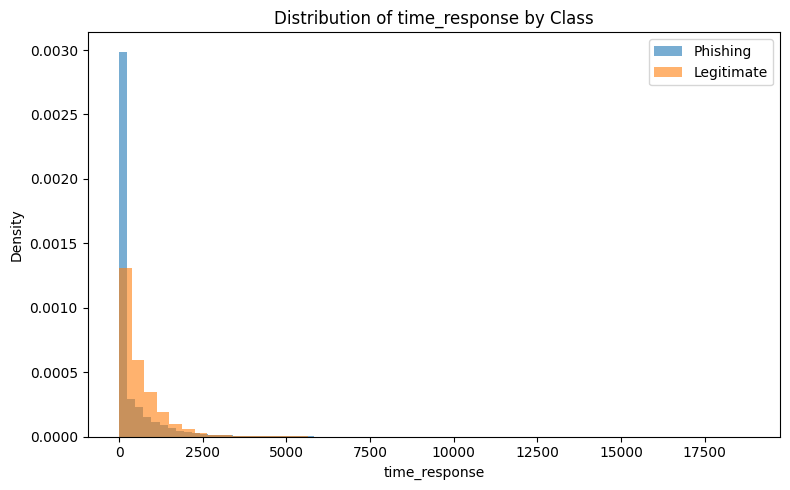


--- Plotting length_url ---


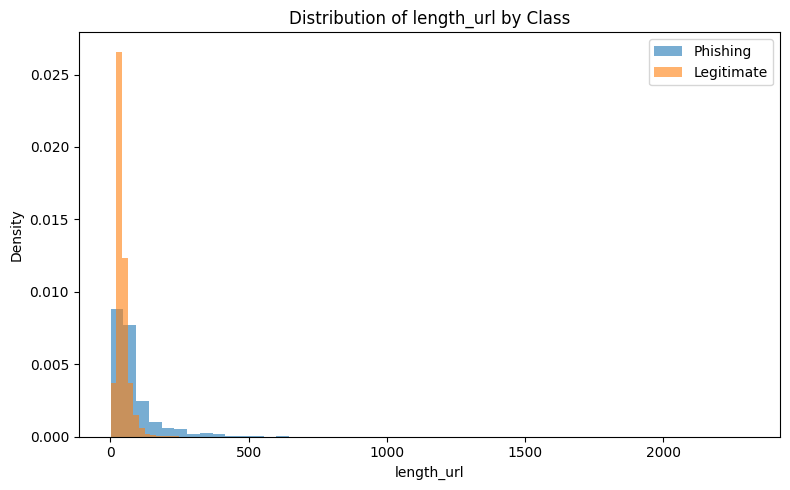


--- Plotting qty_redirects ---


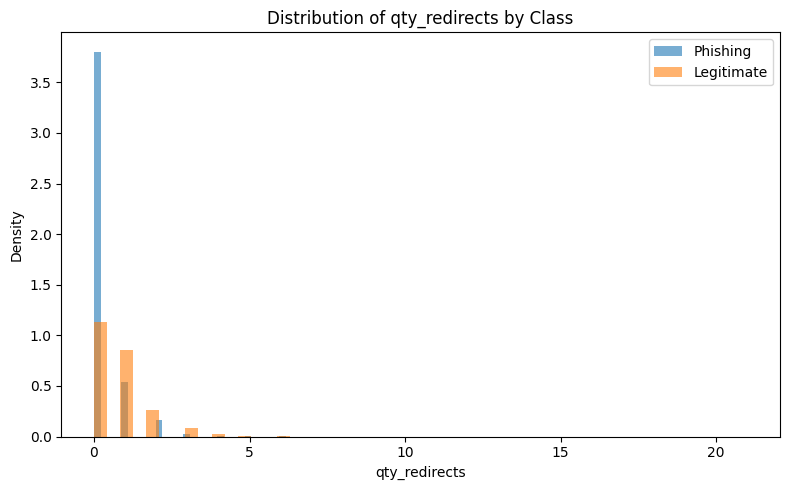


--- Plotting qty_slash_url ---


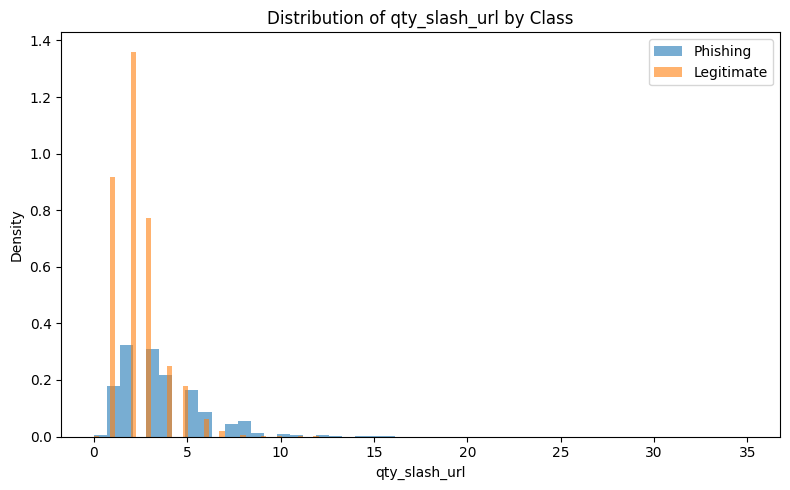


--- Plotting qty_dot_url ---


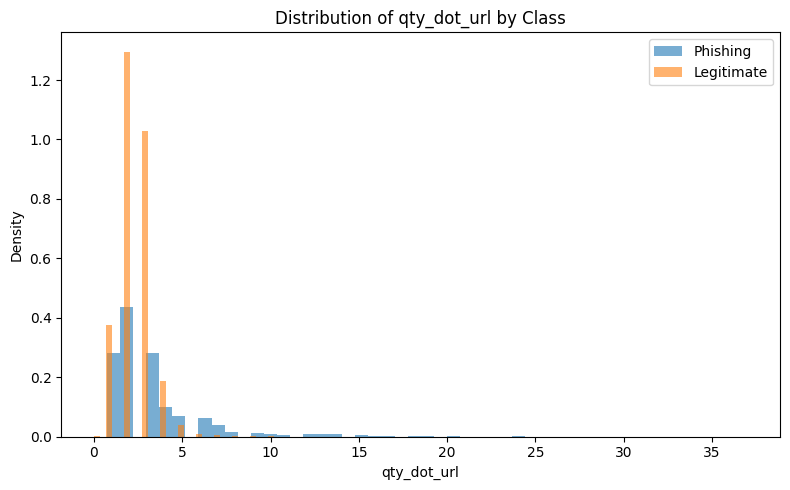


--- Plotting params_length ---


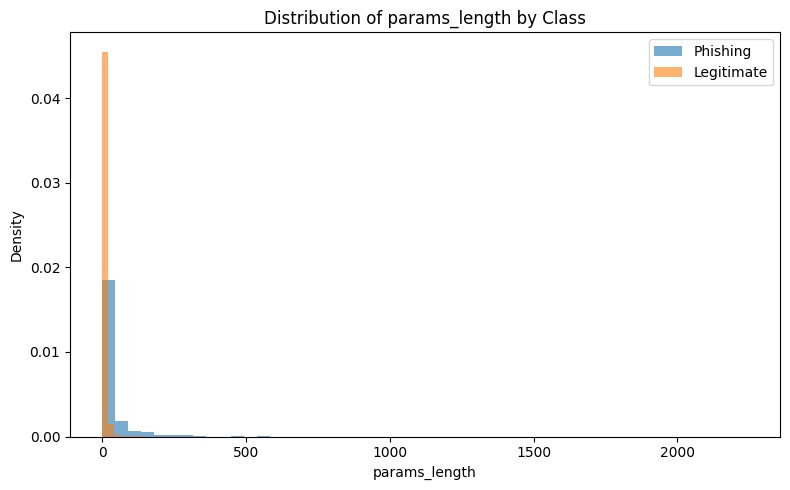


--- Plotting qty_slash_directory ---


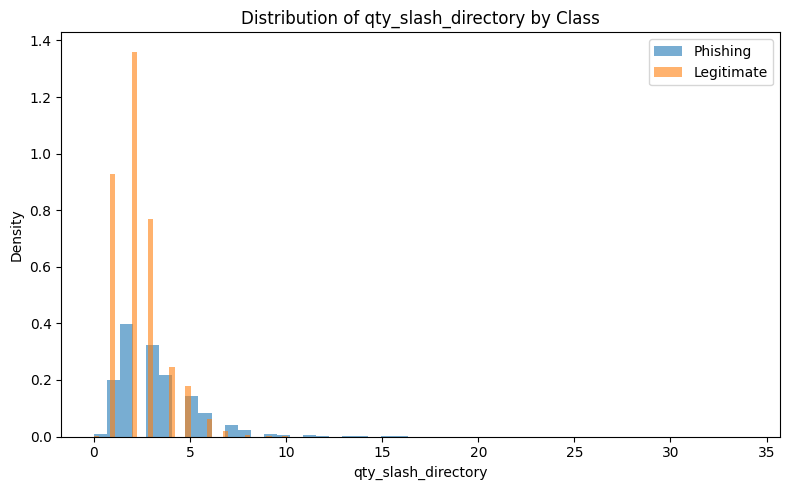


--- Plotting directory_length ---


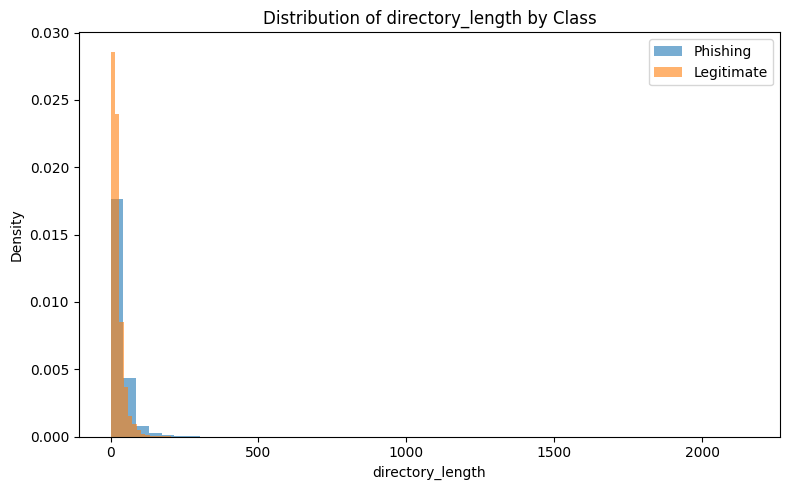


--- Plotting domain_length ---


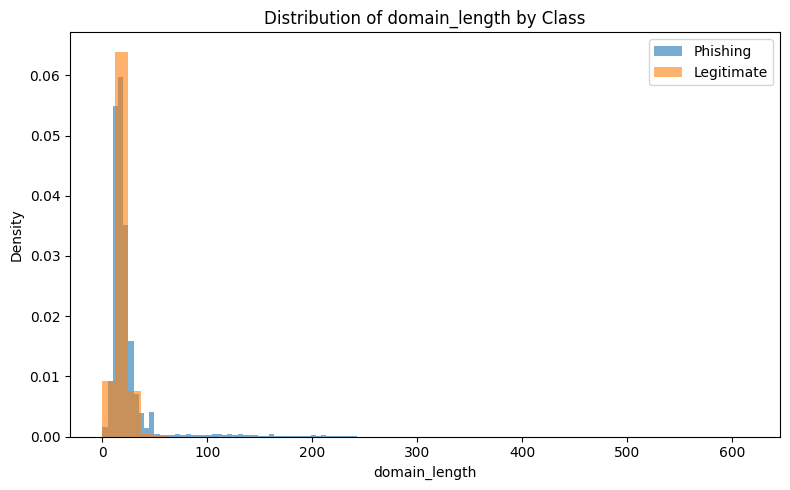


--- Plotting qty_equal_url ---


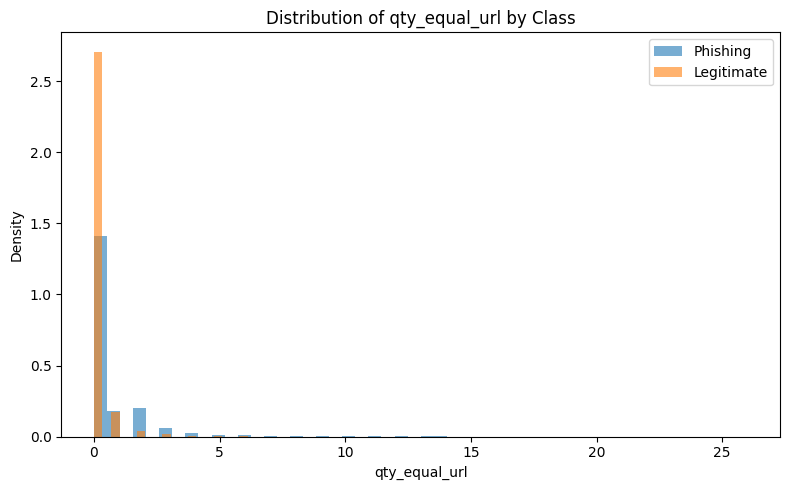


--- Plotting qty_questionmark_url ---


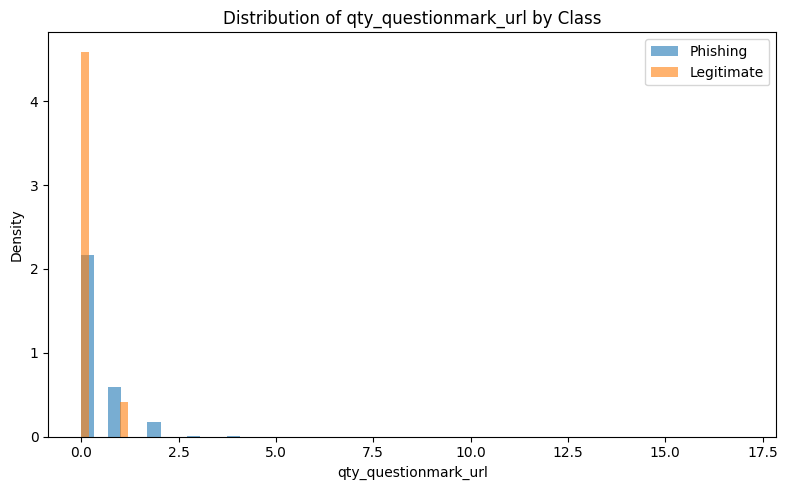


--- Plotting file_length ---


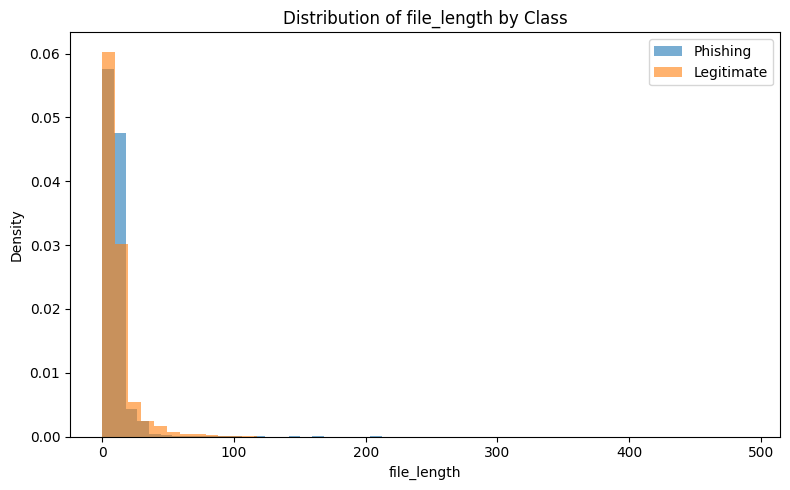


--- Plotting qty_dot_directory ---


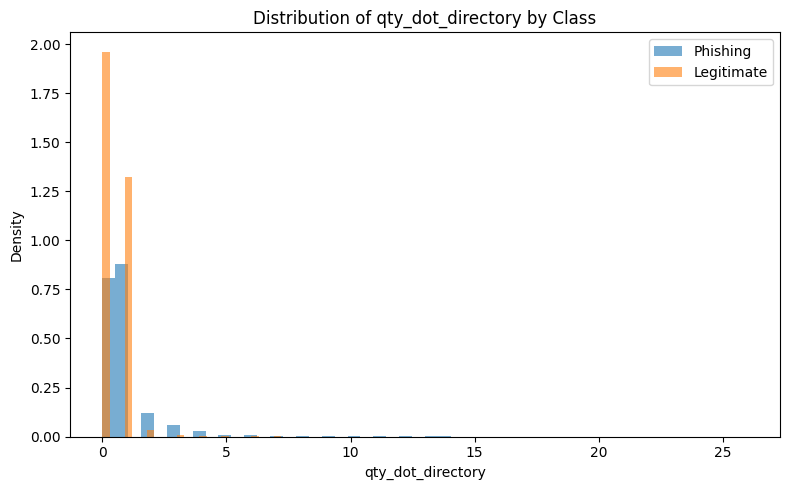


--- Plotting qty_equal_params ---


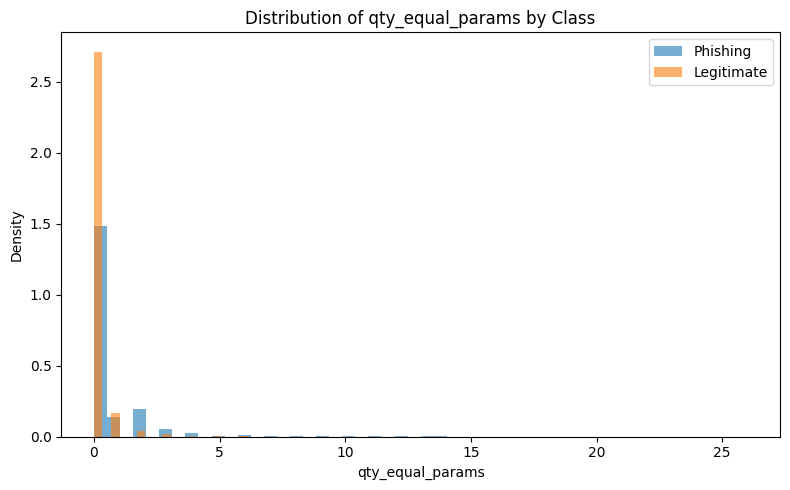


--- Plotting qty_and_url ---


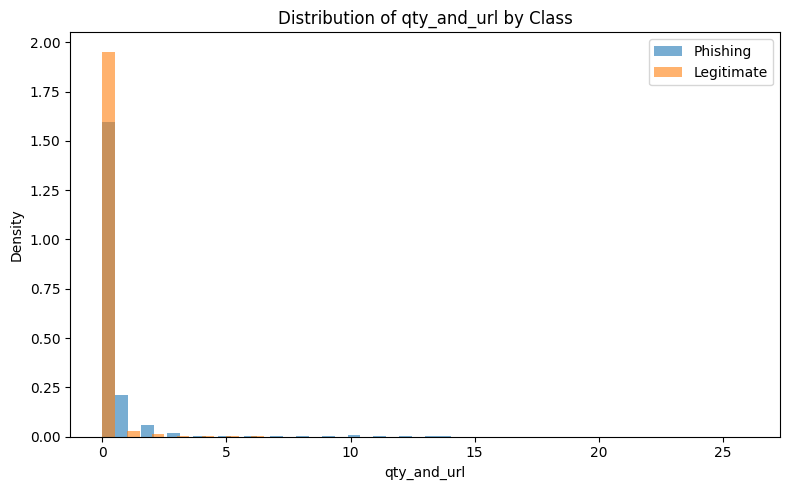


--- Plotting qty_and_params ---


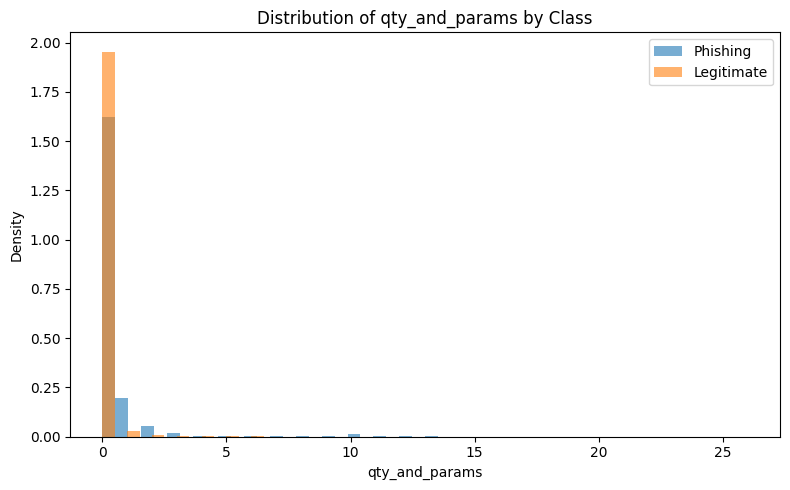


--- Plotting qty_dot_params ---


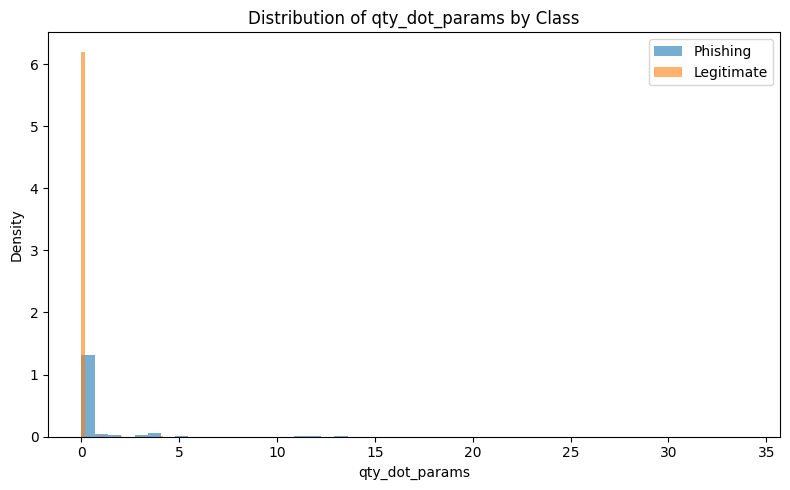


--- Plotting qty_hyphen_params ---


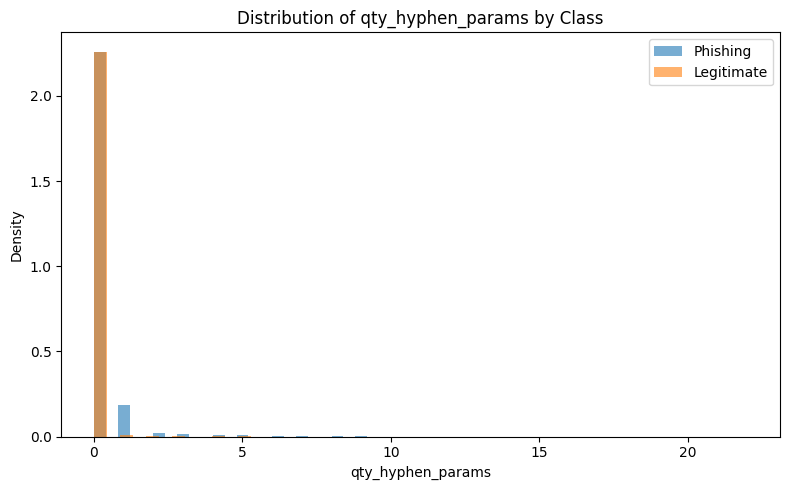

In [33]:
import matplotlib.pyplot as plt

top_features = [
    "http_status",
    "qty_dot_domain",
    "time_response",
    "length_url",
    "qty_redirects",
    "qty_slash_url",
    "qty_dot_url",
    "params_length",
    "qty_slash_directory",
    "directory_length",
    "domain_length",
    "qty_equal_url",
    "qty_questionmark_url",
    "file_length",
    "qty_dot_directory",
    "qty_equal_params",
    "qty_and_url",
    "qty_and_params",
    "qty_dot_params",
    "qty_hyphen_params"
]

def plot_feature_distribution(df, feature, target="Label", bins=50):
    phishing = df[df[target] == 1][feature]
    legit    = df[df[target] == 0][feature]

    plt.figure(figsize=(8, 5))
    plt.hist(phishing, bins=bins, alpha=0.6, label="Phishing", density=True)
    plt.hist(legit,    bins=bins, alpha=0.6, label="Legitimate", density=True)
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"Distribution of {feature} by Class")
    plt.legend()
    plt.tight_layout()
    plt.show()

for feat in top_features:
    if feat in sample_df.columns:
        print(f"\n--- Plotting {feat} ---")
        plot_feature_distribution(sample_df, feat, target="Label")
